<a href="https://colab.research.google.com/github/vinayagarwal5/fullStackDatascience/blob/main/Fruit-Multiclass%20classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
!nvidia-smi

Thu Aug 27 02:06:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [15]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2026-08-27 02:07:28--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 104.192.142.26, 104.192.142.24, 104.192.142.25, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.26|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-08-27 02:07:29 ERROR 404: Not Found.



In [16]:
!unzip fruits.zip

Archive:  fruits.zip
   creating: fruits/
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflatin

In [17]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
tf.__version__

In [18]:
img_height,img_width=32, 32
batch_size = 20
train_ds = tf.keras.utils.image_dataset_from_directory("fruits/train",
                                                       image_size=(img_height, img_width),
                                                       batch_size=batch_size)
val_ds = tf.keras.utils.image_dataset_from_directory("fruits/validation",
                                                     image_size=(img_height, img_width),
                                                     batch_size=batch_size)
test_ds = tf.keras.utils.image_dataset_from_directory("fruits/test",
                                                      image_size=(img_height, img_width),
                                                      batch_size=batch_size)
#

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


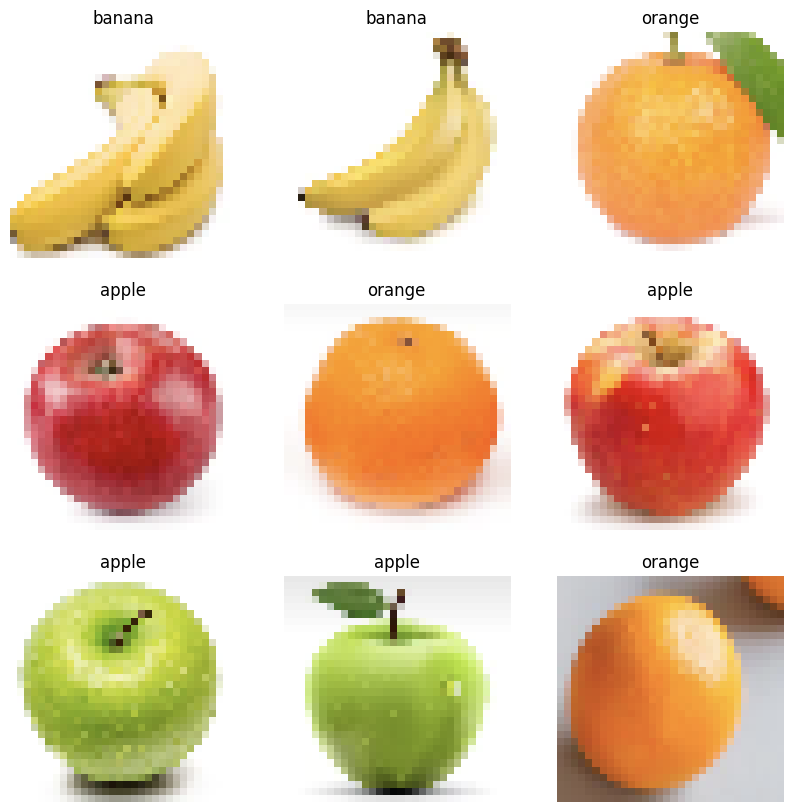

In [19]:
class_names = ["apple","banana","orange"]
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
#

In [24]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(128, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(3)
])

In [25]:
model.compile(
    optimizer="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

In [26]:
model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.5065 - loss: 0.9882 - val_accuracy: 0.8636 - val_loss: 0.6254
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.7848 - loss: 0.5601 - val_accuracy: 0.9242 - val_loss: 0.3532
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - accuracy: 0.8891 - loss: 0.3261 - val_accuracy: 0.7273 - val_loss: 0.7231
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.8957 - loss: 0.3100 - val_accuracy: 0.9697 - val_loss: 0.1689
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.9130 - loss: 0.2220 - val_accuracy: 0.9545 - val_loss: 0.1681
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 111ms/step - accuracy: 0.9304 - loss: 0.1972 - val_accuracy: 0.8788 - val_loss: 0.3637
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - accuracy: 0.9500 - loss: 0.1380 - val_accuracy: 0.9697 - val_loss: 0.1311
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - accuracy: 0.9522 - loss: 0.1477 - val_accuracy: 0.9545 -

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Saved artifact at '/tmp/tmp0x2t_imq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  133781746761808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133781746774096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133781746774480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133781746774672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133781746773904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133781746774864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133781746775824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133781746776208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133781746775632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133781746770256: TensorSpec(shape=(), dtype=tf.r

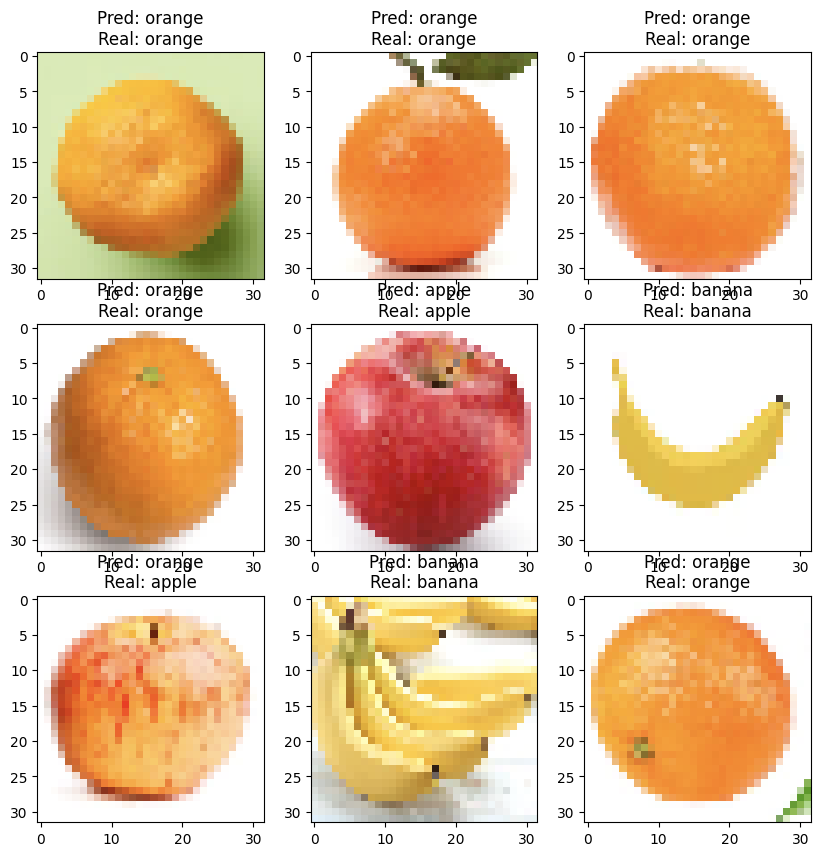

In [29]:
plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
  predictions = model.predict(images)

  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    index = np.argmax(predictions[i])
    plt.title("Pred: " + class_names[index] + "\nReal: " + class_names[labels[i]])

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with tf.io.gfile.GFile('model.tflite', 'wb') as f:
  f.write(tflite_model)